In [238]:
from pathlib import Path
import shutil

# REPLACE 0cc79c26-3350-4e0b-af74-3578c3970157 classes with global ones
'''
In this dataset the obj.names is wrong. Laliotis told me to map like this:
0 flower
1 bud
2 green
3 pink
4 blue
'''
RAW_DATASET_ROOT = Path().cwd().parents[0] / "data" / "raw" / "yolo-classifier-compare" / "0cc79c26-3350-4e0b-af74-3578c3970157"
PROCESSED_DATASET_ROOT = Path().cwd().parents[0] / "data" / "processed" / "yolo-classifier-compare"
(PROCESSED_DATASET_ROOT / "images").mkdir(parents=True, exist_ok=True)
(PROCESSED_DATASET_ROOT / "labels").mkdir(parents=True, exist_ok=True)

GLOBAL_CLASS_DICT = {"bud":0, "buds":0, "Bud":0, 
                     "flower":1, "Flower":1,
                     "green":2, "Green":2, 
                     "pink":3, 
                     "purple":4,
                     "blue":5}


obj_names_path = RAW_DATASET_ROOT /"annotations/obj.names"
local_cls_names = obj_names_path.open(encoding='utf-8').read().splitlines()
for cls_name in local_cls_names:
  if cls_name not in GLOBAL_CLASS_DICT.keys():
    raise ValueError(f"class {cls_name} not in GLOBAL classes")

labels_dir = RAW_DATASET_ROOT / "annotations/obj_train_data"
# images_dir = dataset / "images"

local_class_idx_to_global_map = {i: GLOBAL_CLASS_DICT[cls_name] for i, cls_name in enumerate(local_cls_names)}
print(f"Local class names: {local_cls_names} mapped with: {local_class_idx_to_global_map}")
counter = 0
for label_file in labels_dir.iterdir():
  new_lines = []

  with label_file.open(encoding = 'utf-8') as f:
    for line in f:
      parts = line.strip().split()
      local_cls_idx = int(parts[0])
      # if (local_cls_idx == 4):
      #   # print("iparxei 0")
      #   counter += 1
      global_cls_idx = local_class_idx_to_global_map[local_cls_idx]
      parts[0] = str(global_cls_idx)
      new_lines.append(" ".join(parts))

  # write new label file
  out_label_path = PROCESSED_DATASET_ROOT / "labels" / label_file.name
  # print(out_label_path)

  '''
  out_label_path.write_text("\n".join(new_lines))
  '''

  # copy corresponding image
  img_name = label_file.with_suffix(".png").name
  src_img = RAW_DATASET_ROOT / "images" / img_name
  dst_img = PROCESSED_DATASET_ROOT / "images" / img_name
  # print(img_name)
  # print(src_img)
  # print(dst_img)

  '''
  if src_img.exists():
    shutil.copy(src_img ,dst_img)
    # pass
  else:
    raise ValueError(f"{src_img} does not exist")
  '''

# print(counter)

Local class names: ['flower', 'bud', 'green', 'pink', 'blue'] mapped with: {0: 1, 1: 0, 2: 2, 3: 3, 4: 5}


In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent))

from dataclasses import dataclass
from pathlib import Path
from itertools import islice
from PIL import Image
import yaml
import json
import numpy as np
import torch
import torch.nn as nn
from torchvision.transforms import v2
from ultralytics import YOLO
import matplotlib.pyplot as plt
from sklearn.metrics import  ConfusionMatrixDisplay
from src.utils.metrics import compute_classification_metrics_for_classifier_yolo_comparison

import mlflow
import mlflow.pytorch

# **SOS**: AUTO TO DATASET exei 4:blue anti gia 4:purple -> ta results tou classifier tha einai WRONG!!
# TEST_DATASET_ROOT = Path.home() / Path("BLUEBERRY_DATA/datasets/dataset-c834a7b7") 
# LABELS_DIR = TEST_DATASET_ROOT / "annotations" / "obj_train_data"

# dataset:  0cc79c26-3350-4e0b-af74-3578c3970157
TEST_DATASET_ROOT = Path().cwd().parents[0] / "data" / "processed" / "yolo-classifier-compare"
IMAGES_DIR = TEST_DATASET_ROOT / "images"
LABELS_DIR = TEST_DATASET_ROOT / "labels"
IOU_THRESHOLD = 0.7 # default seems to be 0.7
CONF_THRESHOLD = 0.25 # default seems to be 0.25
DEVICE = "cuda:0"

LABEL_IDS = [0, 1, 2, 3, 4, 5]
CLASS_NAMES = [
    "bud",
    "flower",
    "green",
    "pink",
    "purple",
    "blue"
]

detector = YOLO("yolo_vs_classifier_v1.pt")
# detector.to(DEVICE)

# ==========================================================
# LOAD classifier model
tracking_uri = Path("../experiments/mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{tracking_uri}")
run_id = "531b469fcd5f49ca86d611789277b437"
classifier = mlflow.pytorch.load_model(f"runs:/{run_id}/best_model")
classifier.eval()

mean = [0.4291, 0.5388, 0.3654]
std = [0.1859, 0.2121, 0.1966]
# ==========================================================

inference_transform = v2.Compose([
  v2.ToImage(),
  v2.Resize((64,64)),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=mean, std=std) # depends on which model i choose , what dataset it was trained
])

@dataclass
class BBox:
  cls: int # index
  xc: float # normalized
  yc: float
  w: float
  h: float

  def to_xyxy(self, img_h, img_w) -> tuple[int, int, int, int]:
    x1 = (self.xc - self.w/2) * img_w # x_min
    y1 = (self.yc - self.h/2) * img_h # y_min
    x2 = (self.xc + self.w/2) * img_w # x_max
    y2 = (self.yc + self.h/2) * img_h # y_max
    return int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))


def load_gt(label_file, img_h, img_w):
  '''
  gt bbox = (cls, [x1,y1,x2,y2])
  '''
  gt_boxes = []
  with label_file.open(encoding='utf-8') as f:
    for line in f:
      cls, xc, yc, w, h = map(float, line.split())
      box = BBox(int(cls),xc,yc,w,h)
      x1, y1, x2, y2 = box.to_xyxy(img_h, img_w)
      gt_boxes.append((int(cls), [x1, y1, x2, y2]))

  return gt_boxes

def compute_iou(boxA, boxB):
  xA1, yA1, xA2, yA2 = boxA
  xB1, yB1, xB2, yB2 = boxB

  inter_x1 = max(xA1, xB1)
  inter_y1 = max(yA1, yB1)
  inter_x2 = min(xA2, xB2)
  inter_y2 = min(yA2, yB2)

  inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)

  areaA = (xA2 - xA1) * (yA2 - yA1)
  areaB = (xB2 - xB1) * (yB2 - yB1)

  # union_area = areaA + areaB - inter_area
  return inter_area / (areaA + areaB - inter_area + 1e-6)


/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from scipy.optimize import linear_sum_assignment
# TODO: add hungarian matching for GT - Predicted boxes

def match_detections(gt_boxes, pred_boxes, iou_threshold=0.7):
  '''
  gt_boxes: np.array (N, 4) 
  pred_boxes: np.array (N, 4) 
  '''
  n_gt = len(gt_boxes)
  n_pred = len(pred_boxes)

  if n_gt == 0 or n_pred == 0:
    return [], list(range(n_gt)), list(range(n_pred))

  # IoU matrix
  iou_matrix = np.zeros((n_gt, n_pred), dtype=np.float32)
  for i, gt in enumerate(gt_boxes):
    for j, pred in enumerate(pred_boxes):
      iou_matrix[i, j] = compute_iou(gt, pred)

  # Hungarian minimizes cost
  # so convert IoU -> cost
  cost_matrix = 1.0 - iou_matrix
  gt_indices, pred_indices = linear_sum_assignment(cost_matrix)
  matches = []
  unmatched_gt = set(range(n_gt))
  unmatched_pred = set(range(n_pred))

  for gt_idx, pred_idx in zip(gt_indices, pred_indices):

    iou_score = iou_matrix[gt_idx, pred_idx]
    if iou_score >= iou_threshold:
      matches.append((gt_idx, pred_idx, iou_score))

      unmatched_gt.discard(gt_idx)
      unmatched_pred.discard(pred_idx)

  return (matches, list(unmatched_gt), list(unmatched_pred))


In [18]:
img_h, img_w = 2048, 1536
for label_file in islice(LABELS_DIR.iterdir(), 1):
# for label_file in LABELS_DIR.iterdir():
  gt_boxes = load_gt(label_file, img_h, img_w) # (label, [x1,y1,x2,y2])

  img_file = IMAGES_DIR / label_file.with_suffix('.png').name
  # print(img_file)
  img_rgb = Image.open(img_file).convert("RGB")
  results = detector.predict(
    source=img_file,
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    device=DEVICE,
    verbose=False
  )
  result = results[0]
  pred_boxes = result.boxes.xyxy.cpu().numpy() # (num_dets, 4)
  pred_cls = result.boxes.cls.cpu().numpy() # (num_dets,)
  pred_conf = result.boxes.conf.cpu().numpy() # (num_dets,)

  print(pred_boxes.shape)
  print(np.array([t[1] for t in gt_boxes]).shape)

  matches, unmatched_gt, unmatched_pred = match_detections(
    np.array([t[1] for t in gt_boxes]),
    pred_boxes,
    iou_threshold=IOU_THRESHOLD
  )

  print(f"Matches: {len(matches)}")
  for gt_idx, pred_idx, iou_score in matches:
    gt_cls, gt_box = gt_boxes[gt_idx]
    yolo_pred = int(pred_cls[pred_idx])
    print(f"gt index: {gt_idx} pred index: {pred_idx}")
    print("gt class:", gt_cls)
    print("gt box:", gt_box)
    print(f"pred box: {pred_boxes[pred_idx]}")

  # print(np.array([t[1] for t in gt_boxes]))
  # print([t[1] for t in gt_boxes])

(10, 4)
(245, 4)
Matches: 7
gt index: 1 pred index: 8
gt class: 2
gt box: [804, 1005, 823, 1023]
pred box: [     801.82      1003.2      823.85      1024.9]
gt index: 15 pred index: 2
gt class: 2
gt box: [1430, 1307, 1450, 1327]
pred box: [     1429.3      1305.4      1453.3      1327.6]
gt index: 17 pred index: 0
gt class: 2
gt box: [1225, 932, 1244, 951]
pred box: [     1223.2      929.85      1245.7      951.99]
gt index: 21 pred index: 5
gt class: 2
gt box: [1097, 843, 1116, 862]
pred box: [     1096.1      842.47      1118.4      864.56]
gt index: 26 pred index: 9
gt class: 2
gt box: [1240, 909, 1260, 929]
pred box: [     1238.6      908.39      1263.1      931.14]
gt index: 51 pred index: 6
gt class: 1
gt box: [354, 1092, 373, 1113]
pred box: [     353.39      1090.1      374.87      1111.7]
gt index: 85 pred index: 1
gt class: 1
gt box: [333, 1089, 353, 1110]
pred box: [     330.33      1089.5      351.81      1110.9]


In [ ]:
'''
SOS: Make sure the labels in the dataset I use for validation correspond to the global labels i have 0:bud, 1:flower , etc...
'''
outputs = []
img_h, img_w = 2048, 1536
for label_file in islice(LABELS_DIR.iterdir(), 1):
# for label_file in LABELS_DIR.iterdir():
  gt_boxes = load_gt(label_file, img_h, img_w)
  img_file = IMAGES_DIR / label_file.with_suffix('.png').name
  # print(img_file)
  img_rgb = Image.open(img_file).convert("RGB")
  # results = detector(img_rgb)
  results = detector.predict(
    source=img_file,
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    device=DEVICE,
    verbose=False
  )
  result = results[0]
  pred_boxes = result.boxes.xyxy.cpu().numpy() # (num_dets, 4)
  pred_cls = result.boxes.cls.cpu().numpy() # (num_dets,)
  pred_conf = result.boxes.conf.cpu().numpy() # (num_dets,)
  # print(pred_boxes)

  # for each gt box find the prediction that corresponds to it
  outputs_per_file = []
  already_matched_pred_boxes = set()
  for gt_cls, gt_box in gt_boxes:
    # print(f"ground truth box: {gt_box}")
    best_iou, best_j = 0, -1

    for j, pbox in enumerate(pred_boxes):
      if j in already_matched_pred_boxes:
        continue

      score = compute_iou(gt_box, pbox)
      if score > best_iou:
        best_iou = score
        best_j = j
        # print(f"best {j}, iou score: {score}")

    # past that poing best_j contains the best matching predicted bbox to the gt
    if best_iou < IOU_THRESHOLD:
      # missed prediction, false negative?
      outputs_per_file.append({
        "gt": gt_cls,
        "yolo_pred": None,
        "yolo_conf": None,
        "classifier_pred": None,
        "classifier_conf": None,
        "match": False,
        "iou": None
      })
      # print("didn't match to any detection")
      continue

    already_matched_pred_boxes.add(best_j)
    # print(f"==================================")

    # YOLO class prediction
    yolo_pred = int(pred_cls[best_j])
    yolo_conf = float(pred_conf[best_j])

    # TODO: feed the ground truth to the classifier
    # -----------------------------
    # Crop GT box for classifier
    # -----------------------------
    crop = img_rgb.crop(gt_box) # crop the gt box
    # crop = img_rgb.crop(pred_boxes[best_j]) # crop the detected bbox
    if crop.width < 2 or crop.height < 2:
      continue

    crop_transformed = inference_transform(crop).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
      logits = classifier(crop_transformed).cpu()
    classifier_probs = nn.Softmax(dim=1)(logits).cpu() # (1, n_classes)
    classifier_pred = logits.argmax(dim=1).item()
    classifier_conf = classifier_probs[:, classifier_pred].item()
    # print(logits)
    # print(classifier_probs)
    # print(classifier_pred)
    # print(100*classifier_conf)

    outputs_per_file.append({
      "gt": gt_cls,
      "yolo_pred": yolo_pred,
      "yolo_conf": 100*yolo_conf,
      "classifier_pred": classifier_pred,
      "classifier_conf": 100*classifier_conf,
      "match": True,
      "iou": best_iou
    })

  outputs.extend(outputs_per_file)


1536 2048


[0 1 2 3 5] [0 1 2 3 4 5] [0 1 2 3 4]
IOU = 0.7, confidence = 0.25
CLASSIFIER: 
acc 67.26% | balanced_acc: 61.45% | f1_macro: 38.13% | f1_weighted: 69.37% | precision_macro: 44.44% | precision_weighted: 78.23% | recall_macro: 51.20% | recall_weighted: 67.26%
YOLO:
acc 60.43% | balanced_acc: 50.15% | f1_macro: 24.28% | f1_weighted: 60.50% | precision_macro: 21.16% | precision_weighted: 65.10% | recall_macro: 41.79% | recall_weighted: 60.43%


/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


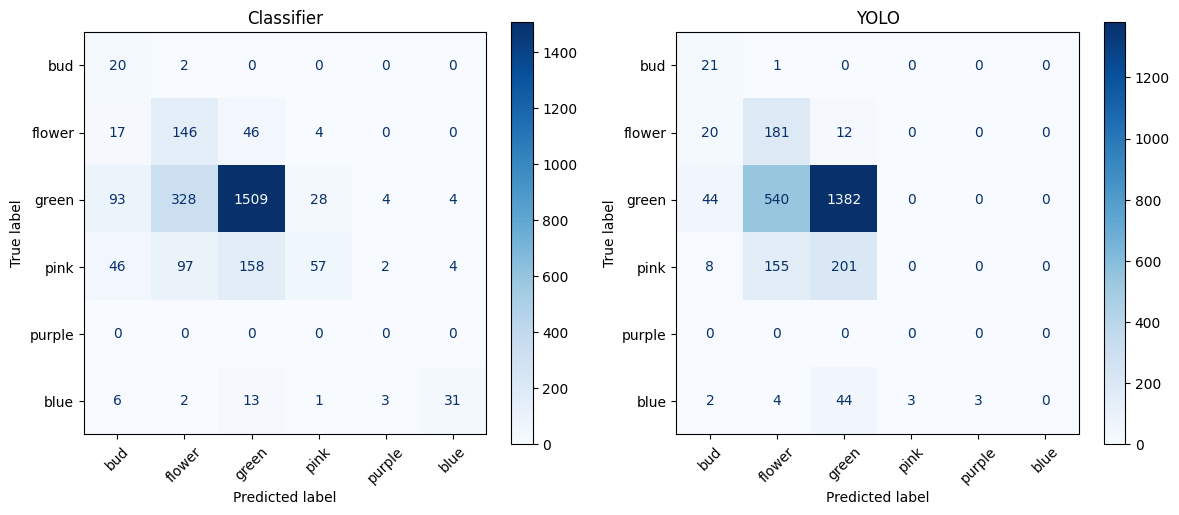

Classifier classification report:
{'0': {'f1-score': 0.19607843137254902,
       'precision': 0.10989010989010989,
       'recall': 0.9090909090909091,
       'support': 22.0},
 '1': {'f1-score': 0.37055837563451777,
       'precision': 0.2539130434782609,
       'recall': 0.6854460093896714,
       'support': 213.0},
 '2': {'f1-score': 0.8174431202600216,
       'precision': 0.8742757821552724,
       'recall': 0.7675483214649034,
       'support': 1966.0},
 '3': {'f1-score': 0.2511013215859031,
       'precision': 0.6333333333333333,
       'recall': 0.1565934065934066,
       'support': 364.0},
 '4': {'f1-score': 0.0, 'precision': 0.0, 'recall': 0.0, 'support': 0.0},
 '5': {'f1-score': 0.6526315789473685,
       'precision': 0.7948717948717948,
       'recall': 0.5535714285714286,
       'support': 56.0},
 'accuracy': 0.6726440289965662,
 'macro avg': {'f1-score': 0.3813021379667266,
               'precision': 0.4443806772881285,
               'recall': 0.5120416791850532,
       

In [29]:
# len(outputs_per_file), len(outputs)
y_true = []
y_yolo = []
y_classifier = []
for d in outputs:
  if d['match']:

    y_true.append(d['gt'])
    y_yolo.append(d['yolo_pred'])
    y_classifier.append(d['classifier_pred'])

print(np.unique(y_true), np.unique(y_classifier), np.unique(y_yolo))

classifier_metrics = compute_classification_metrics_for_classifier_yolo_comparison(y_classifier, y_true, LABEL_IDS)
classifier_per_class_report = classifier_metrics['classification_report']
yolo_metrics = compute_classification_metrics_for_classifier_yolo_comparison(y_yolo, y_true, LABEL_IDS)
yolo_per_class_report = yolo_metrics['classification_report']
print(f"IOU = {IOU_THRESHOLD}, confidence = {CONF_THRESHOLD}")

print(f"CLASSIFIER: ")
print(
  f"acc {classifier_metrics['acc']:.2f}% | "
  f"balanced_acc: {classifier_metrics['balanced_acc']:.2f}% | "
  f"f1_macro: {classifier_metrics['f1_macro']:.2f}% | "
  f"f1_weighted: {classifier_metrics['f1_weighted']:.2f}% | "
  f"precision_macro: {classifier_metrics['precision_macro']:.2f}% | "
  f"precision_weighted: {classifier_metrics['precision_weighted']:.2f}% | "
  f"recall_macro: {classifier_metrics['recall_macro']:.2f}% | "
  f"recall_weighted: {classifier_metrics['recall_weighted']:.2f}%"
)

print(f"YOLO:")
print(
  f"acc {yolo_metrics['acc']:.2f}% | "
  f"balanced_acc: {yolo_metrics['balanced_acc']:.2f}% | "
  f"f1_macro: {yolo_metrics['f1_macro']:.2f}% | "
  f"f1_weighted: {yolo_metrics['f1_weighted']:.2f}% | "
  f"precision_macro: {yolo_metrics['precision_macro']:.2f}% | "
  f"precision_weighted: {yolo_metrics['precision_weighted']:.2f}% | "
  f"recall_macro: {yolo_metrics['recall_macro']:.2f}% | "
  f"recall_weighted: {yolo_metrics['recall_weighted']:.2f}%"
)

classifier_conf_matrix = classifier_metrics['confusion_matrix']
fig, ax = plt.subplots(1, 2, figsize=(12,5))
disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix, display_labels=CLASS_NAMES)
# disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix)
disp_conf_matrix.plot(ax=ax[0], cmap=plt.cm.Blues, xticks_rotation=45)
ax[0].set_title("Classifier")

yolo_conf_matrix = yolo_metrics['confusion_matrix']
disp_conf_matrix = ConfusionMatrixDisplay(yolo_conf_matrix, display_labels=CLASS_NAMES)
disp_conf_matrix.plot(ax=ax[1], cmap=plt.cm.Blues, xticks_rotation=45)
ax[1].set_title("YOLO")
plt.tight_layout()
plt.show()


from pprint import pprint
# print(json.dumps(classifier_per_class_report, indent=2))
print(f"Classifier classification report:")
pprint(classifier_per_class_report)
print(f"YOLO classification report:")
pprint(yolo_per_class_report)

In [ ]:
[0 1 2 3 5] [0 1 2 3 4 5] [0 1 2 3 4]
IOU = 0.7, confidence = 0.25
CLASSIFIER: 
acc 69.17% | balanced_acc: 61.89% | f1_macro: 38.71% | f1_weighted: 70.72% | precision_macro: 44.87% | precision_weighted: 78.64% | recall_macro: 51.58% | recall_weighted: 69.17%
YOLO:
acc 60.43% | balanced_acc: 50.15% | f1_macro: 24.28% | f1_weighted: 60.50% | precision_macro: 21.16% | precision_weighted: 65.10% | recall_macro: 41.79% | recall_weighted: 60.43%
/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true

In [ ]:
[0 1 2 3 5] [0 1 2 3 5] [0 1 2]
IOU = 0.7, confidence = 0.25
CLASSIFIER: 
acc 76.15% | balanced_acc: 64.34% | f1_macro: 49.84% | f1_weighted: 77.68% | precision_macro: 56.77% | precision_weighted: 82.34% | recall_macro: 64.34% | recall_weighted: 76.15%
YOLO:
acc 69.25% | balanced_acc: 50.30% | f1_macro: 29.59% | f1_weighted: 71.37% | precision_macro: 27.04% | precision_weighted: 78.09% | recall_macro: 50.30% | recall_weighted: 69.25%


In [224]:
# detector = YOLO("yolo_vs_classifier_v1.pt")
# print(detector.overrides)
print(detector.predictor.args)

task=detect
mode=predict
model=yolo_vs_classifier_v1.pt
data=/data/dataset_prep_cache/e7c5961371a9/data.yaml
epochs=100
time=None
patience=100
batch=1
imgsz=512
save=False
save_period=-1
cache=False
device=cuda:0
workers=8
project=None
name=None
exist_ok=False
pretrained=True
optimizer=auto
verbose=False
seed=0
deterministic=True
single_cls=False
rect=True
cos_lr=False
close_mosaic=10
resume=False
amp=True
fraction=1.0
profile=False
freeze=None
multi_scale=0.0
compile=False
overlap_mask=True
mask_ratio=4
dropout=0.0
val=True
split=val
save_json=False
conf=0.25
iou=0.7
max_det=300
half=False
dnn=False
plots=True
end2end=None
source=None
vid_stride=1
stream_buffer=False
visualize=False
augment=False
agnostic_nms=False
classes=None
retina_masks=False
embed=None
show=False
save_frames=False
save_txt=False
save_conf=False
save_crop=False
show_labels=True
show_conf=True
show_boxes=True
line_width=None
format=torchscript
keras=False
optimize=False
int8=False
dynamic=False
simplify=True
opset=

In [82]:
detector = YOLO("yolo_vs_classifier_v1.pt")
print(detector.model.args)
print(detector.overrides)

{'task': 'detect', 'data': '/data/dataset_prep_cache/e7c5961371a9/data.yaml', 'imgsz': 512, 'single_cls': False, 'model': 'yolo_vs_classifier_v1.pt'}
{'task': 'detect', 'data': '/data/dataset_prep_cache/e7c5961371a9/data.yaml', 'imgsz': 512, 'single_cls': False, 'model': 'yolo_vs_classifier_v1.pt'}
